In [1]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import numpy as np
import cv2
import os
from captum.attr import IntegratedGradients, Occlusion, LayerGradCam, LayerAttribution

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [2]:
# recria a arquitetura como no treino
from torchvision.models import resnet50, ResNet50_Weights

model_resnet = resnet50(weights=None)  # sem pesos, vamos carregar os teus
model_resnet.fc = nn.Linear(model_resnet.fc.in_features, 2)  # 2 classes (ajuste se for diferente)

path_resnet = r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\4-redes\2.resnet\normal\modelos_salvos_resnet\resnet_fold5.pth"

state = torch.load(path_resnet, map_location=device)
model_resnet.load_state_dict(state)
model_resnet.to(device)
model_resnet.eval()


C:\Users\sthem\AppData\Local\Temp\ipykernel_5084\3267427631.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(path_resnet, map_location=device)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [3]:
normalize_imagenet = transforms.Normalize(
    mean=(0.485, 0.456, 0.406),
    std=(0.229, 0.224, 0.225)
)

transform_rgb = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    normalize_imagenet,
])

transform_gray = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    normalize_imagenet,
])

def load_image(path, mode="gray"):
    img = Image.open(path)
    if mode == "rgb":
        img = img.convert("RGB")
        x = transform_rgb(img)
    else:
        x = transform_gray(img)
    return img, x.unsqueeze(0).to(device)  # PIL + tensor (1,3,224,224)


## IG

In [4]:
def explain_ig(model, x, target=None, n_steps=50, baseline=None):
    model.zero_grad()
    model.eval()

    # classe alvo
    if target is None:
        with torch.no_grad():
            target = model(x).argmax(dim=1).item()

    # se não passar baseline, usa preto por padrão
    if baseline is None:
        baseline = torch.zeros_like(x)

    ig = IntegratedGradients(model)
    attributions, _ = ig.attribute(
        x,
        baselines=baseline,
        target=target,
        n_steps=n_steps,
        return_convergence_delta=True
    )

    # agrega canais e normaliza para [0,1]
    attr = attributions.abs().sum(dim=1, keepdim=True)
    attr = (attr - attr.min()) / (attr.max() - attr.min() + 1e-8)
    return attr.detach().cpu(), target


## Occlusion

In [5]:
def explain_occlusion(model, x, target=None, window=15, stride=8, baseline=0):
    model.zero_grad()
    model.eval()

    if target is None:
        with torch.no_grad():
            target = model(x).argmax(dim=1).item()

    occ = Occlusion(model)
    attributions = occ.attribute(
        x,
        strides=(3, stride, stride),
        sliding_window_shapes=(3, window, window),
        baselines=baseline,
        target=target
    )

    attr = attributions.mean(dim=1, keepdim=True)
    attr = (attr - attr.min()) / (attr.max() - attr.min() + 1e-8)
    return attr.detach().cpu(), target


## Grad-CAM

In [6]:
resnet_layer = model_resnet.layer4[-1]  # último bloco residual

def explain_gradcam_resnet(x, target=None):
    model_resnet.zero_grad()
    model_resnet.eval()

    if target is None:
        with torch.no_grad():
            target = model_resnet(x).argmax(dim=1).item()

    gradcam = LayerGradCam(model_resnet, resnet_layer)
    attributions = gradcam.attribute(x, target=target)

    upsampled = LayerAttribution.interpolate(attributions, x.shape[2:])
    attr = (upsampled - upsampled.min()) / (upsampled.max() - upsampled.min() + 1e-8)
    return attr.detach().cpu(), target


## DeepLIFT

In [11]:
from captum.attr import DeepLift

def explain_deeplift(model, x, target=None, baseline=None):
    model.zero_grad()
    model.eval()

    if target is None:
        with torch.no_grad():
            target = model(x).argmax(dim=1).item()

    if baseline is None:
        baseline = torch.zeros_like(x)

    deeplift = DeepLift(model)
    attributions = deeplift.attribute(x, baselines=baseline, target=target)

    attr = attributions.abs().sum(dim=1, keepdim=True)
    attr = (attr - attr.min()) / (attr.max() - attr.min() + 1e-8)
    return attr.detach().cpu(), target


## Salvando overlays

In [7]:
def save_overlay(pil_img, heatmap, out_path, alpha=0.5):
    """
    pil_img: PIL original
    heatmap: tensor (1,1,H,W) normalizado [0,1]
    """
    img = np.array(pil_img.resize((heatmap.shape[-1], heatmap.shape[-2])))
    if img.ndim == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    else:
        img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

    hm = heatmap.squeeze().numpy()
    hm = (hm * 255).astype(np.uint8)
    hm_color = cv2.applyColorMap(hm, cv2.COLORMAP_JET)

    overlay = cv2.addWeighted(img, 1 - alpha, hm_color, alpha, 0)
    cv2.imwrite(out_path, overlay)


## Rodando XAI exemplo

In [ ]:
img_path = r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\img_dir_annot_jpg\train\infected\2022_03_21_11_02_58_05_cell0012.png"  # cinza, por exemplo
pil_img, x = load_image(img_path, mode="gray")

with torch.no_grad():
    logits = model_resnet(x)
    pred = logits.argmax(1).item()
print("Predição ResNet:", pred)

# b1 = imagem preta
baseline_b1 = torch.zeros_like(x)
ig_b1, _ = explain_ig(model_resnet, x, target=pred, baseline=baseline_b1)

# b2 = imagem "lavada" (mesmo que preta no seu caso, mas deixei separado)
baseline_b2 = x * 0
ig_b2, _ = explain_ig(model_resnet, x, target=pred, baseline=baseline_b2)

# b3 = imagem cinza
baseline_b3 = torch.ones_like(x) * 0.5
ig_b3, _ = explain_ig(model_resnet, x, target=pred, baseline=baseline_b3)

occ_map, _  = explain_occlusion(model_resnet, x, target=pred)
gc_map, _   = explain_gradcam_resnet(x, target=pred)
dl_map, _ = explain_deeplift(resnet, x, target=pred)

os.makedirs("xai_resnet_test", exist_ok=True)
save_overlay(pil_img, ig_b1, "xai_resnet_test/ig_overlay_b1.png")
save_overlay(pil_img, ig_b2, "xai_resnet_test/ig_overlay_b2.png")
save_overlay(pil_img, ig_b3, "xai_resnet_test/ig_overlay_b3.png")
save_overlay(pil_img, occ_map, "xai_resnet_test/occ_overlay.png")
save_overlay(pil_img, gc_map,  "xai_resnet_test/gc_overlay.png")
save_overlay(pil_img, dl_map, "xai_resnet/deeplift_overlay.png")


Predição ResNet: 0


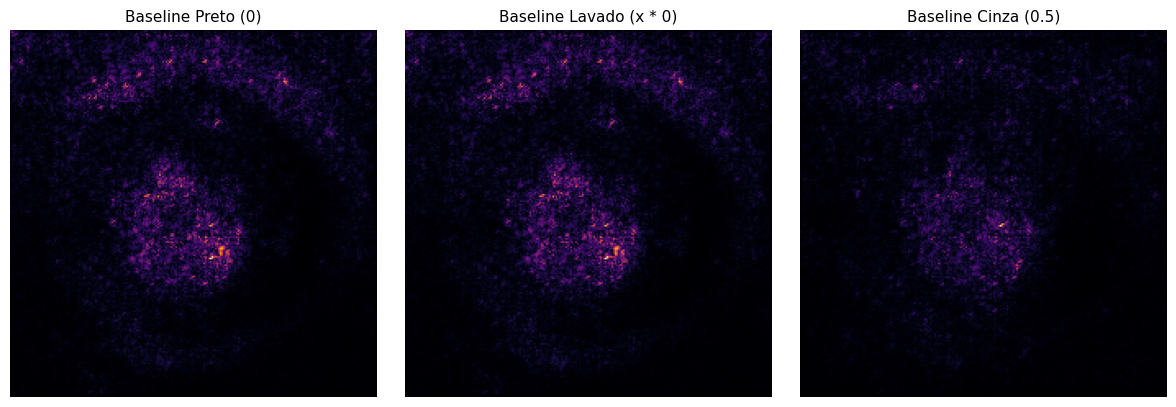

In [9]:
import matplotlib.pyplot as plt
import numpy as np

ig_b1_np = ig_b1.squeeze().numpy()
ig_b2_np = ig_b2.squeeze().numpy()
ig_b3_np = ig_b3.squeeze().numpy()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

titles = ['Baseline Preto (0)', 'Baseline Lavado (x * 0)', 'Baseline Cinza (0.5)']
imgs = [ig_b1_np, ig_b2_np, ig_b3_np]

for ax, img, title in zip(axes, imgs, titles):
    ax.imshow(img, cmap='inferno')
    ax.set_title(title, fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.show()


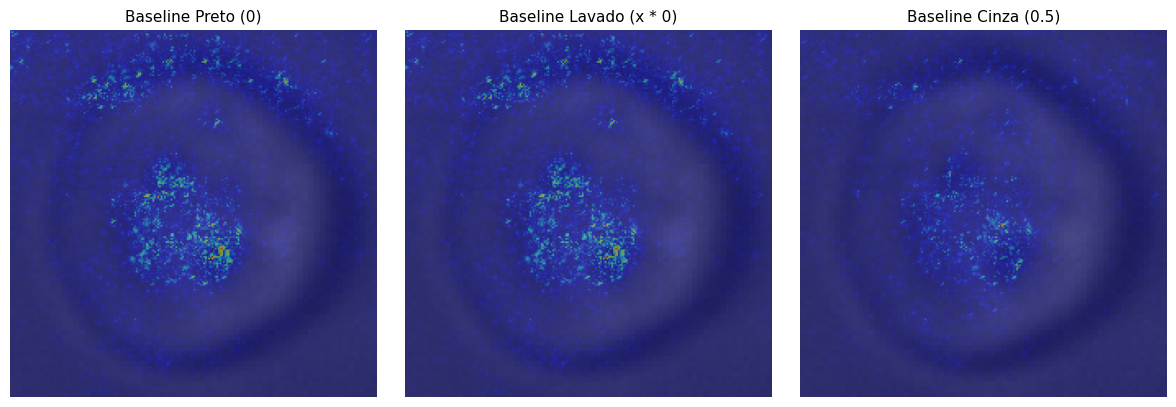

In [10]:
orig = np.array(pil_img.resize((224, 224)))

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, img, title in zip(axes, imgs, titles):
    ax.imshow(orig, cmap='gray')
    ax.imshow(img, cmap='jet', alpha=0.5)
    ax.set_title(title, fontsize=11)
    ax.axis('off')
plt.tight_layout()
plt.show()
